NN Cost: 1146.40
NN Routes: [[30, 26, 16, 12, 1, 7, 14, 29, 22, 18], [24, 27, 20, 5, 25, 10, 8], [13, 21, 31, 19, 17, 3, 23], [6, 2, 28, 4, 11, 9], [15]]
✓ Solution is feasible


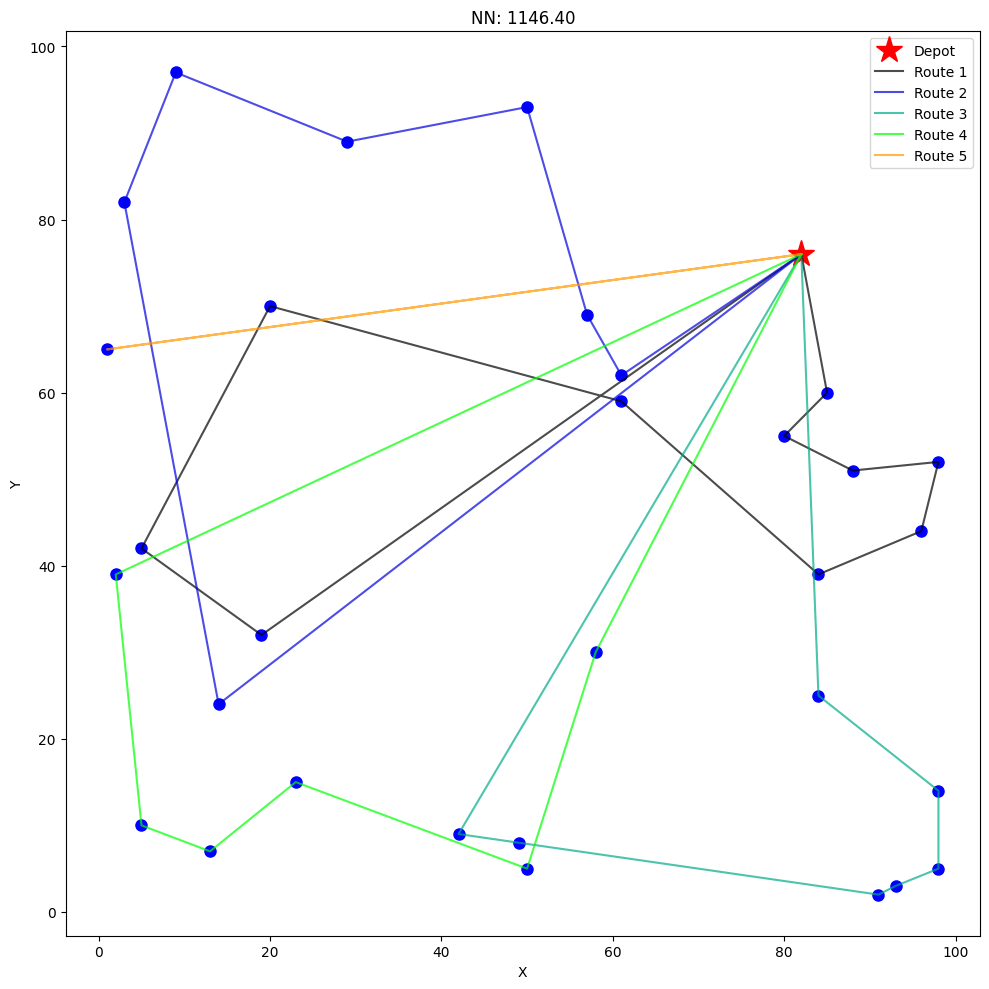


Optimal Cost: 784.00
NN Gap: 46.22%

NN + 2-opt Cost: 1124.21
Improvement: 22.19 (1.9%)
2-opt Routes: [[30, 26, 16, 12, 1, 7, 18, 22, 29, 14], [24, 8, 10, 25, 5, 20, 27], [13, 21, 31, 19, 17, 3, 23], [6, 2, 28, 4, 11, 9], [15]]
✓ Solution is feasible


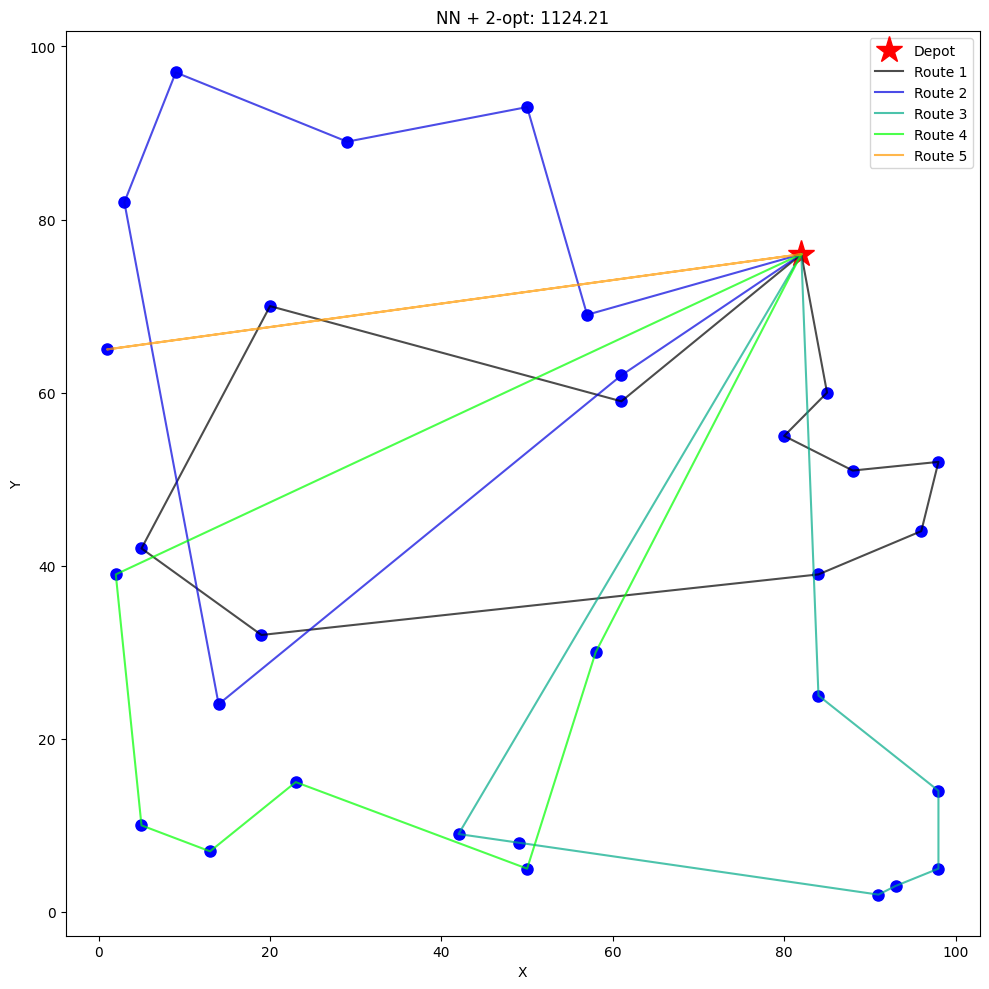


Optimal Cost: 784.00
NN + 2-opt Gap: 43.39%


In [2]:
# Setup
import os
os.chdir('/Users/gauravchoudhary/Desktop/github/VRP')

import numpy as np
import matplotlib.pyplot as plt
from parsers.vrp_parser import parse_vrp_instance, parse_vrp_solution
from solvers.nearest_neighbor import get_nn_solution
from solvers.local_search import get_2opt_refinements
from utils.validation import get_solution_validation, get_validation_report
from utils.visualization import get_solution_visual

problem = 'A-n32-k5'
vrp_filepath = os.path.join('data/instances', f'{problem}.vrp')
sol_filepath = os.path.join('data/solutions', f'{problem}.sol')

instance = parse_vrp_instance(vrp_filepath)
optimal = parse_vrp_solution(sol_filepath)

# Nearest neighbor: solution + validation + visualization + benchmarking

solution_nn = get_nn_solution(instance)

print(f'NN Cost: {solution_nn.cost:.2f}')
print(f'NN Routes: {solution_nn.routes}')

report_nn = get_solution_validation(solution_nn.routes, instance)
get_validation_report(report_nn)

get_solution_visual(instance, solution_nn, title = f'NN: {solution_nn.cost:.2f}', colormap = 'nipy_spectral')

print(f'\nOptimal Cost: {optimal.cost:.2f}')
print(f'NN Gap: {100 * (solution_nn.cost / optimal.cost - 1):.2f}%')

# Nearest neighbor + 2-opt refinement: solution + validation + visualization + benchmarking

solution_2opt = get_2opt_refinements(instance, solution_nn)

print(f'\nNN + 2-opt Cost: {solution_2opt.cost:.2f}')
print(f'Improvement: {solution_nn.cost - solution_2opt.cost:.2f} ({100 * (1 - solution_2opt.cost / solution_nn.cost):.1f}%)')
print(f'2-opt Routes: {solution_2opt.routes}')

report_2opt = get_solution_validation(solution_2opt.routes, instance)
get_validation_report(report_2opt)

get_solution_visual(instance, solution_2opt, title = f'NN + 2-opt: {solution_2opt.cost:.2f}', colormap = 'nipy_spectral')

print(f'\nOptimal Cost: {optimal.cost:.2f}')
print(f'NN + 2-opt Gap: {100 * (solution_2opt.cost / optimal.cost - 1):.2f}%')